Cleaned dataset saved as 'sleep_survey_clean.csv'
Number of observations: 103
                            OLS Regression Results                            
Dep. Variable:           productivity   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.252
Method:                 Least Squares   F-statistic:                     124.9
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           1.36e-52
Time:                        17:22:51   Log-Likelihood:                -93.720
No. Observations:                 103   AIC:                             223.4
Df Residuals:                      85   BIC:                             270.9
Df Model:                          17                                         
Covariance Type:                  HC1                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

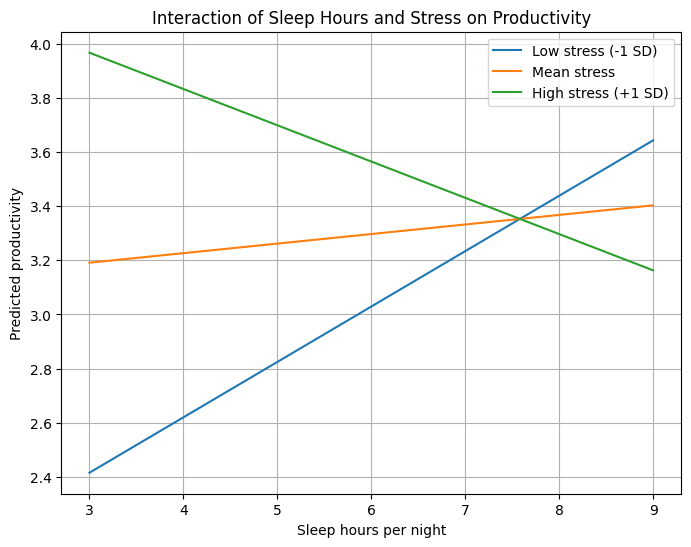

sleep quality stress interation
                            OLS Regression Results                            
Dep. Variable:           productivity   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     124.3
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           1.63e-52
Time:                        17:22:52   Log-Likelihood:                -95.197
No. Observations:                 103   AIC:                             226.4
Df Residuals:                      85   BIC:                             273.8
Df Model:                          17                                         
Covariance Type:                  HC1                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 15
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 16
  warnings.warn('covariance of constraints does not have full '


In [ ]:
# sleep_productivity_pipeline.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



RAW_FILE = "sleep productivity values.csv"

# Read file
df_raw = pd.read_csv(RAW_FILE)

df_raw = df_raw.iloc[1:].reset_index(drop=True)



# Cleaning file
cols_keep = [
    "Q3", "Q4", "Q5", "Q6", "Q7",
    "Q8", "Q9", "Q10", "Q11",
    "Q12", "Q13", "Q14", "Q15",
    "Q17", "Q18", "Q19", "Q20", "Q21"
]

df_raw = df_raw[cols_keep].copy()

# Make a working copy
df = df_raw.copy()

# Convert everything to numeric
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

#RECODE / RENAME VARIABLES

# ---- Sleep: Q3 (hours per night) -> midpoints ----
# Choices assumed ordered: 1=<4, 2=4–5, 3=6–7, 4=7–8, 5=>8
sleep_hours_map = {
    1: 3.0,   # <4
    2: 4.5,   # 4–5
    3: 6.5,   # 6–7
    4: 7.5,   # 7–8
    5: 9.0    # >8
}
df["sleep_hours"] = df["Q3"].map(sleep_hours_map)

# ---- Sleep consistency: Q4 (1–5 already, just rename) ----
df["sleep_consistency"] = df["Q4"]

# ---- Sleep quality: Q5 (1–5 already) ----
df["sleep_quality"] = df["Q5"]

# ---- Nap frequency: Q6 ----
# 1=Never, 2=1–2/week, 3=3–4/week, 4=5+/week
nap_freq_map = {
    1: 0,  # Never
    2: 1,
    3: 2,
    4: 3
}
df["nap_freq"] = df["Q6"].map(nap_freq_map)

# ---- Nap duration: Q7 ----
# 1=<20 min, 2=20–40, 3=40–60, 4=>60
df["nap_duration"] = df["Q7"]

# ---- Caffeinated drinks: Q8 (0–4+ coded 1–5 likely) ----
# 1=0, 2=1, 3=2, 4=3, 5=4+
caff_drinks_map = {
    1: 0,
    2: 1,
    3: 2,
    4: 3,
    5: 4
}
df["caffeine_drinks"] = df["Q8"].map(caff_drinks_map)

# ---- Caffeine mg: Q21 ----
# 1=0 mg, 2=1–100, 3=101–200, 4=201–300, 5=301–400, 6=>400
# (If only 5 categories in your version, adjust this mapping)
caff_mg_map = {
    1: 0,
    2: 1,
    3: 2,
    4: 3,
    5: 4,
    6: 5
}
df["caffeine_mg"] = df["Q21"].map(caff_mg_map)

# ---- Exercise frequency: Q9 ----
# 1=0, 2=1–2, 3=3–4, 4=5+
ex_freq_map = {
    1: 0,
    2: 1,
    3: 2,
    4: 3
}
df["exercise_freq"] = df["Q9"].map(ex_freq_map)

# ---- Exercise duration: Q10 ----
# 1=<30, 2=30–60, 3=1–2h, 4=>2h
df["exercise_duration"] = df["Q10"]

# ---- Stress level: Q11 (1–5) ----
df["stress"] = df["Q11"]

# ---- Productivity (DV): Q12 (1–5) ----
df["productivity"] = df["Q12"]

# ---- Study hours per day: Q13 -> midpoints ----
# 1=<1, 2=1–2, 3=2–3, 4=5–6, 5=>6
study_hours_map = {
    1: 0.5,
    2: 1.5,
    3: 2.5,
    4: 5.5,
    5: 7.0
}
df["study_hours"] = df["Q13"].map(study_hours_map)

# ---- GPA range: Q14 -> midpoints ----
# 1=<2.5, 2=2.5–2.9, 3=3.0–3.4, 4=3.5–3.9, 5=4.0
gpa_map = {
    1: 2.25,
    2: 2.7,
    3: 3.2,
    4: 3.7,
    5: 4.0
}
df["gpa"] = df["Q14"].map(gpa_map)

# ---- Sleep impacts academics: Q15 (0–4 style) ----
# 1=Never, 2=Rarely, 3=Sometimes, 4=Often, 5=Always
sleep_impact_map = {
    1: 0,
    2: 1,
    3: 2,
    4: 3,
    5: 4
}
df["sleep_impacts_academics"] = df["Q15"].map(sleep_impact_map)

# ---- Gender: Q17 ----
# Assume: 1=Male, 2=Female, 3=Non-binary/Third gender, 4=Prefer not to say
df["gender"] = df["Q17"]
df["female"] = (df["gender"] == 2).astype(int)
df["nonbinary"] = (df["gender"] == 3).astype(int)
df["gender_prefer_notsay"] = (df["gender"] == 4).astype(int)

# ---- Age: Q18 ----
# 1=18, 2=19, 3=20, 4=21, 5=22, 6=23+
age_map = {
    1: 18,
    2: 19,
    3: 20,
    4: 21,
    5: 22,
    6: 23.5
}
df["age"] = df["Q18"].map(age_map)

# ---- Academic year: Q19 ----
# 1=Freshman, 2=Sophomore, 3=Junior, 4=Senior
df["year"] = df["Q19"]
df["sophomore"] = (df["year"] == 2).astype(int)
df["junior"] = (df["year"] == 3).astype(int)
df["senior"] = (df["year"] == 4).astype(int)

# ---- Work status: Q20 ----
# Assume: 1=Yes, part-time; 2=Yes, full-time; 3=No
work_map = {
    1: 1,  # part-time
    2: 2,  # full-time
    3: 0   # no job
}
df["work_status"] = df["Q20"].map(work_map)
df["work_parttime"] = (df["work_status"] == 1).astype(int)
df["work_fulltime"] = (df["work_status"] == 2).astype(int)

# 3. DERIVED VARIABLES

# (Optional) Center variables before interaction to help interpretation:
# ---- CENTER VARIABLES (recommended for interaction models) ----
df["sleep_c"] = df["sleep_hours"] - df["sleep_hours"].mean()
df["stress_c"] = df["stress"] - df["stress"].mean()
df["female_c"] = df["female"] - df["female"].mean()

# Interaction using centered variables
df["sleep_stress_interaction_c"] = df["sleep_c"] * df["stress_c"]
df["female_stress_interaction_c"] = df["female_c"] * df["stress_c"]

# Quadratic term for sleep
df["sleep_hours_sq"] = df["sleep_hours"] ** 2

# Interaction: sleep × stress
df["sleep_stress_interaction"] = df["sleep_hours"] * df["stress"]

# 4. BASIC CLEANING

# Drop rows with missing key variables (e.g., productivity or sleep_hours)
key_vars = ["productivity", "sleep_hours", "stress"]
df_clean = df.dropna(subset=key_vars).reset_index(drop=True)

#  5. SAVE CLEAN DATA

df_clean.to_csv("sleep_survey_clean.csv", index=False)
print("Cleaned dataset saved as 'sleep_survey_clean.csv'")
print("Number of observations:", len(df_clean))

# 6. (OPTIONAL) REGRESSION TEMPLATE

import statsmodels.formula.api as smf

# Example full model with interaction and robust SEs
formula = """
productivity ~ sleep_hours + sleep_quality + sleep_consistency +
               nap_freq + caffeine_mg + stress + exercise_freq + study_hours + gpa +
               work_parttime + work_fulltime + female + nonbinary +
               sophomore + junior + senior +
               sleep_stress_interaction_c
"""

model = smf.ols(formula=formula, data=df_clean).fit(cov_type="HC1")
print(model.summary())

import statsmodels.formula.api as smf

print("\n==============================")
print("MODEL 1: Stress → Sleep Quality")
print("==============================")
m1 = smf.ols(
    "sleep_quality ~ stress + gender + gpa + exercise_freq + caffeine_mg",
    data=df_clean
).fit(cov_type="HC1")
print(m1.summary())


print("\n==============================")
print("MODEL 2: Stress → Sleep Hours")
print("==============================")
m2 = smf.ols(
    "sleep_hours ~ stress + gender + gpa + exercise_freq + caffeine_mg",
    data=df_clean
).fit(cov_type="HC1")
print(m2.summary())


print("\n==============================")
print("MODEL 3: Stress → Sleep Consistency")
print("==============================")
m3 = smf.ols(
    "sleep_consistency ~ stress + gender + gpa + exercise_freq + study_hours",
    data=df_clean
).fit(cov_type="HC1")
print(m3.summary())


print("\n==============================")
print("MODEL 4: Stress → Nap Frequency")
print("==============================")
m4 = smf.ols(
    "nap_freq ~ stress + gender + gpa + exercise_freq + study_hours",
    data=df_clean
).fit(cov_type="HC1")
print(m4.summary())


print("\n==============================")
print("MODEL 5: Stress → Nap Duration")
print("==============================")
m5 = smf.ols(
    "nap_duration ~ stress + gender + gpa + exercise_freq + study_hours",
    data=df_clean
).fit(cov_type="HC1")
print(m5.summary())

formula_main = """
productivity ~ sleep_hours + sleep_quality + sleep_consistency +
               nap_freq + caffeine_mg + stress + exercise_freq + study_hours + gpa +
               work_parttime + work_fulltime + female + nonbinary +
               sophomore + junior + senior +
               sleep_stress_interaction_c
"""

model_main = smf.ols(formula=formula_main, data=df_clean).fit(cov_type="HC1")
print(model_main.summary())

# ---------------------------------------------------
# 2. Build prediction grid for interaction plot
# ---------------------------------------------------

# Get mean and SD of stress (UNcentered stress variable)
stress_mean = df_clean["stress"].mean()
stress_sd   = df_clean["stress"].std()

# Define 3 stress levels: low, mean, high
stress_levels = {
    "Low stress (-1 SD)": stress_mean - stress_sd,
    "Mean stress":        stress_mean,
    "High stress (+1 SD)":stress_mean + stress_sd
}

# Sleep range for plotting
sleep_min, sleep_max = df_clean["sleep_hours"].min(), df_clean["sleep_hours"].max()
sleep_grid = np.linspace(sleep_min, sleep_max, 100)

# Hold other controls at their sample means (or modes for dummies)
controls_means = {
    "sleep_quality": df_clean["sleep_quality"].mean(),
    "sleep_consistency": df_clean["sleep_consistency"].mean(),
    "nap_freq": df_clean["nap_freq"].mean(),
    "caffeine_mg": df_clean["caffeine_mg"].mean(),
    "exercise_freq": df_clean["exercise_freq"].mean(),
    "study_hours": df_clean["study_hours"].mean(),
    "gpa": df_clean["gpa"].mean(),
    "work_parttime": df_clean["work_parttime"].mean(),
    "work_fulltime": df_clean["work_fulltime"].mean(),
    "female": df_clean["female"].mean(),
    "nonbinary": df_clean["nonbinary"].mean(),
    "sophomore": df_clean["sophomore"].mean(),
    "junior": df_clean["junior"].mean(),
    "senior": df_clean["senior"].mean(),
}

pred_dfs = []

for label, stress_val in stress_levels.items():
    temp = pd.DataFrame({
        "sleep_hours": sleep_grid,
        "stress": stress_val
    })

    # Recompute centered interaction for each stress level
    temp["sleep_c"] = temp["sleep_hours"] - df_clean["sleep_hours"].mean()
    temp["stress_c"] = temp["stress"] - stress_mean
    temp["sleep_stress_interaction_c"] = temp["sleep_c"] * temp["stress_c"]

    # Add controls at means
    for k,v in controls_means.items():
        temp[k] = v

    temp["stress_label"] = label
    pred_dfs.append(temp)

pred_grid = pd.concat(pred_dfs, ignore_index=True)

# Predict productivity
pred_grid["pred_productivity"] = model_main.predict(pred_grid)

# ---------------------------------
# 3. Plot the interaction lines
# ---------------------------------
plt.figure(figsize=(8,6))

for label in stress_levels.keys():
    subset = pred_grid[pred_grid["stress_label"] == label]
    plt.plot(subset["sleep_hours"], subset["pred_productivity"], label=label)

plt.xlabel("Sleep hours per night")
plt.ylabel("Predicted productivity")
plt.title("Interaction of Sleep Hours and Stress on Productivity")
plt.legend()
plt.grid(True)
plt.show()


print("sleep quality stress interation")

# Center sleep quality and stress to avoid multicollinearity
df_clean["sleep_quality_c"] = df_clean["sleep_quality"] - df_clean["sleep_quality"].mean()
df_clean["stress_c"] = df_clean["stress"] - df_clean["stress"].mean()

# Interaction term
df_clean["sq_stress_interaction"] = df_clean["sleep_quality_c"] * df_clean["stress_c"]

# Regression model
formula_sq = """
productivity ~ sleep_quality_c + stress_c + sq_stress_interaction +
               sleep_hours + sleep_consistency + nap_freq + caffeine_mg +
               exercise_freq + study_hours + gpa +
               work_parttime + work_fulltime + female + nonbinary +
               sophomore + junior + senior
"""

model_sq = smf.ols(formula=formula_sq, data=df_clean).fit(cov_type="HC1")
print(model_sq.summary())


import numpy as np
import statsmodels.formula.api as smf

# Make sure we are using the cleaned data
df_clean = pd.read_csv("sleep_survey_clean.csv")

print("\n======================================")
print("MEDIATION TESTS: Stress -> Productivity")
print("======================================")

# Step 1: Productivity on stress only
med1 = smf.ols(
    "productivity ~ stress",
    data=df_clean
).fit(cov_type="HC1")
print("\nMEDIATION STEP 1: productivity ~ stress")
print(med1.summary())

# Step 2: Productivity on stress + sleep variables
med2 = smf.ols(
    "productivity ~ stress + sleep_hours + sleep_quality + sleep_consistency + nap_freq",
    data=df_clean
).fit(cov_type="HC1")
print("\nMEDIATION STEP 2: productivity ~ stress + sleep variables")
print(med2.summary())


print("\n======================================")
print("SPLIT-SAMPLE REGRESSIONS: Low vs High Stress")
print("======================================")

# Median split on stress
stress_median = df_clean["stress"].median()
df_clean["stress_group"] = np.where(df_clean["stress"] >= stress_median, "High", "Low")

formula_main = """
productivity ~ sleep_hours + sleep_quality + sleep_consistency +
               nap_freq + caffeine_mg + stress + exercise_freq + study_hours + gpa +
               work_parttime + work_fulltime + female + nonbinary +
               sophomore + junior + senior +
               sleep_stress_interaction_c
"""

# Low stress subsample
low = df_clean[df_clean["stress_group"] == "Low"]
model_low = smf.ols(formula=formula_main, data=low).fit(cov_type="HC1")
print("\nMAIN MODEL – LOW STRESS SUBSAMPLE")
print(model_low.summary())

# High stress subsample
high = df_clean[df_clean["stress_group"] == "High"]
model_high = smf.ols(formula=formula_main, data=high).fit(cov_type="HC1")
print("\nMAIN MODEL – HIGH STRESS SUBSAMPLE")
print(model_high.summary())


print("\n======================================")
print("APPENDIX MODELS: Sleep Quality -> Sleep Structure")
print("======================================")

# Sleep consistency on sleep quality
sq1 = smf.ols(
    "sleep_consistency ~ sleep_quality + stress + gpa + exercise_freq",
    data=df_clean
).fit(cov_type="HC1")
print("\nMODEL A1: sleep_consistency ~ sleep_quality + controls")
print(sq1.summary())

# Nap frequency on sleep quality
sq2 = smf.ols(
    "nap_freq ~ sleep_quality + stress + gpa + exercise_freq",
    data=df_clean
).fit(cov_type="HC1")
print("\nMODEL A2: nap_freq ~ sleep_quality + controls")
print(sq2.summary())


print("\n======================================")
print("OPTIONAL APPENDIX: Stress -> Sleep Hours Squared")
print("======================================")

# If not already created, make the squared term
if "sleep_hours_sq" not in df_clean.columns:
    df_clean["sleep_hours_sq"] = df_clean["sleep_hours"] ** 2

sq3 = smf.ols(
    "sleep_hours_sq ~ stress + gender + gpa + exercise_freq + caffeine_mg",
    data=df_clean
).fit(cov_type="HC1")
print("\nMODEL A3: sleep_hours_sq ~ stress + controls")
print(sq3.summary())

python SleepStre.py > results.txt



In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Prepare the data for VIF calculation
# Exclude the dependent variable and any categorical dummy variables that are perfectly collinear
X = df_clean[[
    "sleep_hours", "sleep_quality", "sleep_consistency",
    "nap_freq", "caffeine_mg", "stress", "exercise_freq", "study_hours", "gpa",
    "work_parttime", "work_fulltime", "female", "nonbinary",
    "sophomore", "junior", "senior",
    "sleep_stress_interaction_c"
]]

# Add a constant term for the intercept, as VIF expects this
X = sm.add_constant(X)

# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("Variance Inflation Factor (VIF) values:")
display(vif_data.sort_values(by="VIF", ascending=False))

Variance Inflation Factor (VIF) values:


,feature,VIF
0,const,209.790393
13,nonbinary,3.362288
16,senior,2.802331
17,sleep_stress_interaction_c,2.503964
15,junior,1.912553
1,sleep_hours,1.908085
14,sophomore,1.826267
3,sleep_consistency,1.765423
11,work_fulltime,1.551414
2,sleep_quality,1.525797


In [ ]:
import pandas as pd

# Robust SEs already in model_main
coefs = model_main.params
ses   = model_main.bse
pvals = model_main.pvalues

# Add significance stars
def stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

table = pd.DataFrame({
    "Coefficient": coefs,
    "Robust SE (HC1)": ses,
    "p-value": pvals,
    "": [stars(p) for p in pvals]
})

# Optional: nicer rounding
table_rounded = table.copy()
table_rounded["Coefficient"] = table_rounded["Coefficient"].round(3)
table_rounded["Robust SE (HC1)"] = table_rounded["Robust SE (HC1)"].round(3)
table_rounded["p-value"] = table_rounded["p-value"].round(3)

print(table_rounded)

# Save for paper
table_rounded.to_csv("main_regression_table.csv")
print("\nSaved: main_regression_table.csv")


                            Coefficient  Robust SE (HC1)  p-value    
Intercept                         0.315            1.052    0.765    
sleep_hours                       0.035            0.082    0.666    
sleep_quality                     0.257            0.117    0.027  **
sleep_consistency                 0.006            0.077    0.943    
nap_freq                         -0.210            0.088    0.017  **
caffeine_mg                      -0.026            0.063    0.682    
stress                            0.132            0.107    0.217    
exercise_freq                     0.084            0.089    0.346    
study_hours                       0.117            0.047    0.014  **
gpa                               0.375            0.184    0.041  **
work_parttime                    -0.142            0.162    0.380    
work_fulltime                     0.235            0.440    0.594    
female                           -0.136            0.173    0.432    
nonbinary           

In [ ]:
# Select all variables used in regression
vars_list = [
    "productivity", "sleep_hours", "sleep_quality", "sleep_consistency",
    "nap_freq", "caffeine_mg", "exercise_freq", "study_hours",
    "gpa", "stress",
    "female", "nonbinary",
    "sophomore", "junior", "senior",
    "work_parttime", "work_fulltime"
]

summary = df[vars_list].describe().T
summary["mean"] = summary["mean"].round(3)
summary["std"] = summary["std"].round(3)
summary["min"] = summary["min"].round(3)
summary["max"] = summary["max"].round(3)

# Keep only the needed columns
table1 = summary[["mean", "std", "min", "max"]]

print(table1)

# Save to CSV for easy table import
table1.to_csv("summary_statistics_table.csv")
print("\nSaved summary statistics to summary_statistics_table.csv")

                    mean    std   min  max
productivity       3.359  0.765  1.00  5.0
sleep_hours        6.952  1.018  3.00  9.0
sleep_quality      3.190  0.735  1.00  5.0
sleep_consistency  2.743  1.169  1.00  5.0
nap_freq           0.590  0.863  0.00  3.0
caffeine_mg        1.596  1.219  0.00  4.0
exercise_freq      1.817  0.943  0.00  3.0
study_hours        2.607  1.511  0.50  7.0
gpa                3.265  0.404  2.25  4.0
stress             2.990  0.818  1.00  5.0
female             0.274  0.448  0.00  1.0
nonbinary          0.009  0.094  0.00  1.0
sophomore          0.150  0.359  0.00  1.0
junior             0.168  0.376  0.00  1.0
senior             0.434  0.498  0.00  1.0
work_parttime      0.336  0.475  0.00  1.0
work_fulltime      0.062  0.242  0.00  1.0

Saved summary statistics to summary_statistics_table.csv


In [ ]:
import pandas as pd

df_clean = pd.read_csv("sleep_survey_clean.csv")

vars_list = [
    "productivity", "sleep_hours", "sleep_quality", "sleep_consistency",
    "nap_freq", "caffeine_mg", "exercise_freq", "study_hours",
    "gpa", "stress",
    "female", "nonbinary",
    "sophomore", "junior", "senior",
    "work_parttime", "work_fulltime"
]

table1 = df_clean[vars_list].describe().T
table1 = table1[["mean", "std", "min", "max"]].round(3)

print(table1)

table1.to_csv("Table1_SummaryStats.csv")
print("Saved Table 1 as Table1_SummaryStats.csv")

                    mean    std   min  max
productivity       3.359  0.765  1.00  5.0
sleep_hours        6.942  1.025  3.00  9.0
sleep_quality      3.184  0.738  1.00  5.0
sleep_consistency  2.738  1.171  1.00  5.0
nap_freq           0.602  0.867  0.00  3.0
caffeine_mg        1.583  1.217  0.00  4.0
exercise_freq      1.825  0.944  0.00  3.0
study_hours        2.607  1.511  0.50  7.0
gpa                3.265  0.404  2.25  4.0
stress             2.990  0.822  1.00  5.0
female             0.301  0.461  0.00  1.0
nonbinary          0.010  0.099  0.00  1.0
sophomore          0.165  0.373  0.00  1.0
junior             0.184  0.390  0.00  1.0
senior             0.476  0.502  0.00  1.0
work_parttime      0.369  0.485  0.00  1.0
work_fulltime      0.068  0.253  0.00  1.0
Saved Table 1 as Table1_SummaryStats.csv


In [ ]:
import statsmodels.formula.api as smf
import pandas as pd

df_clean = pd.read_csv("sleep_survey_clean.csv")

formula_main = """
productivity ~ sleep_hours + sleep_quality + sleep_consistency +
               nap_freq + caffeine_mg + stress + exercise_freq + study_hours + gpa +
               work_parttime + work_fulltime + female + nonbinary +
               sophomore + junior + senior +
               sleep_stress_interaction_c
"""

model_main = smf.ols(formula=formula_main, data=df_clean).fit(cov_type="HC1")

coefs = model_main.params
ses   = model_main.bse
pvals = model_main.pvalues

def stars(p):
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""

table2 = pd.DataFrame({
    "Coefficient": coefs.round(3),
    "Robust_SE_HC1": ses.round(3),
    "p_value": pvals.round(3),
    "Signif": [stars(p) for p in pvals]
})

print(table2)

table2.to_csv("Table2_MainRegression.csv")
print("Saved Table 2 as Table2_MainRegression.csv")

                            Coefficient  Robust_SE_HC1  p_value Signif
Intercept                         0.315          1.052    0.765       
sleep_hours                       0.035          0.082    0.666       
sleep_quality                     0.257          0.117    0.027     **
sleep_consistency                 0.006          0.077    0.943       
nap_freq                         -0.210          0.088    0.017     **
caffeine_mg                      -0.026          0.063    0.682       
stress                            0.132          0.107    0.217       
exercise_freq                     0.084          0.089    0.346       
study_hours                       0.117          0.047    0.014     **
gpa                               0.375          0.184    0.041     **
work_parttime                    -0.142          0.162    0.380       
work_fulltime                     0.235          0.440    0.594       
female                           -0.136          0.173    0.432       
nonbin

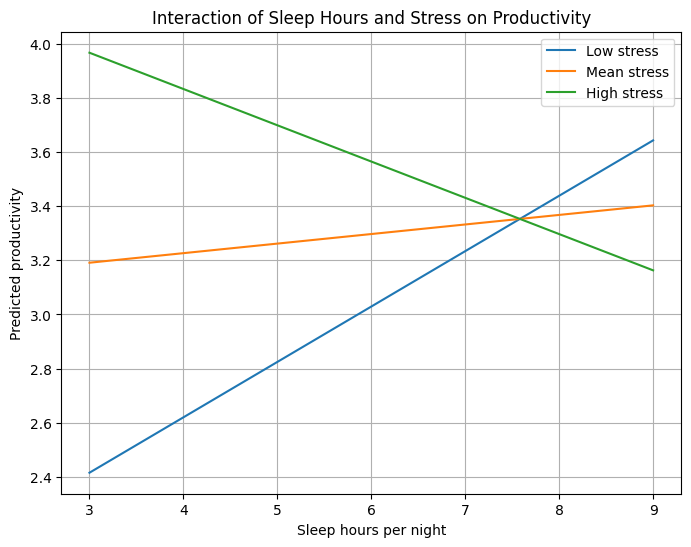

Saved Figure 1 as Figure1_InteractionPlot.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df_clean = pd.read_csv("sleep_survey_clean.csv")

formula_main = """
productivity ~ sleep_hours + sleep_quality + sleep_consistency +
               nap_freq + caffeine_mg + stress + exercise_freq + study_hours + gpa +
               work_parttime + work_fulltime + female + nonbinary +
               sophomore + junior + senior +
               sleep_stress_interaction_c
"""

model_main = smf.ols(formula=formula_main, data=df_clean).fit(cov_type="HC1")

stress_mean = df_clean["stress"].mean()
stress_sd   = df_clean["stress"].std()

stress_levels = {
    "Low stress": stress_mean - stress_sd,
    "Mean stress": stress_mean,
    "High stress": stress_mean + stress_sd
}

sleep_min, sleep_max = df_clean["sleep_hours"].min(), df_clean["sleep_hours"].max()
sleep_grid = np.linspace(sleep_min, sleep_max, 100)

controls_means = {
    "sleep_quality": df_clean["sleep_quality"].mean(),
    "sleep_consistency": df_clean["sleep_consistency"].mean(),
    "nap_freq": df_clean["nap_freq"].mean(),
    "caffeine_mg": df_clean["caffeine_mg"].mean(),
    "exercise_freq": df_clean["exercise_freq"].mean(),
    "study_hours": df_clean["study_hours"].mean(),
    "gpa": df_clean["gpa"].mean(),
    "work_parttime": df_clean["work_parttime"].mean(),
    "work_fulltime": df_clean["work_fulltime"].mean(),
    "female": df_clean["female"].mean(),
    "nonbinary": df_clean["nonbinary"].mean(),
    "sophomore": df_clean["sophomore"].mean(),
    "junior": df_clean["junior"].mean(),
    "senior": df_clean["senior"].mean()
}

pred_dfs = []

for label, stress_val in stress_levels.items():
    temp = pd.DataFrame({
        "sleep_hours": sleep_grid,
        "stress": stress_val
    })

    temp["sleep_c"] = temp["sleep_hours"] - df_clean["sleep_hours"].mean()
    temp["stress_c"] = temp["stress"] - stress_mean
    temp["sleep_stress_interaction_c"] = temp["sleep_c"] * temp["stress_c"]

    for k, v in controls_means.items():
        temp[k] = v

    temp["stress_label"] = label
    pred_dfs.append(temp)

pred_grid = pd.concat(pred_dfs, ignore_index=True)
pred_grid["pred_productivity"] = model_main.predict(pred_grid)

plt.figure(figsize=(8,6))

for label in stress_levels.keys():
    sub = pred_grid[pred_grid["stress_label"] == label]
    plt.plot(sub["sleep_hours"], sub["pred_productivity"], label=label)

plt.xlabel("Sleep hours per night")
plt.ylabel("Predicted productivity")
plt.title("Interaction of Sleep Hours and Stress on Productivity")
plt.legend()
plt.grid(True)

plt.savefig("Figure1_InteractionPlot.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved Figure 1 as Figure1_InteractionPlot.png")

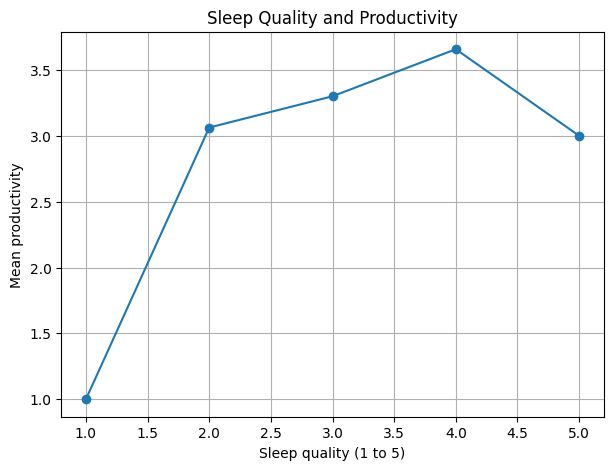

Saved Figure 2 as Figure2_SleepQuality_Productivity.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_clean = pd.read_csv("sleep_survey_clean.csv")

means = df_clean.groupby("sleep_quality")["productivity"].mean()

plt.figure(figsize=(7,5))
plt.plot(means.index, means.values, marker="o")

plt.xlabel("Sleep quality (1 to 5)")
plt.ylabel("Mean productivity")
plt.title("Sleep Quality and Productivity")
plt.grid(True)

plt.savefig("Figure2_SleepQuality_Productivity.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved Figure 2 as Figure2_SleepQuality_Productivity.png")

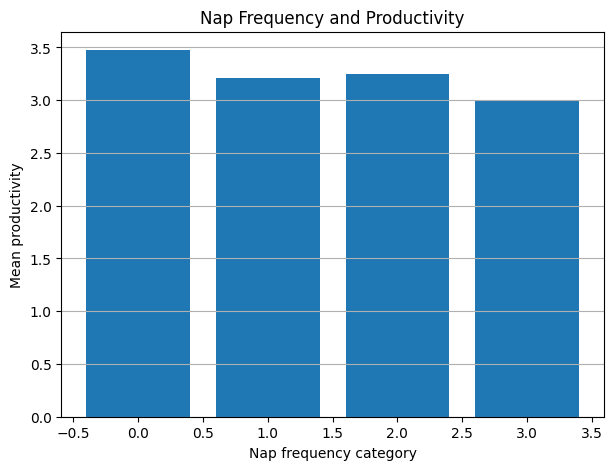

Saved Figure 3 as Figure3_NapFreq_Productivity.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_clean = pd.read_csv("sleep_survey_clean.csv")

means = df_clean.groupby("nap_freq")["productivity"].mean()

plt.figure(figsize=(7,5))
plt.bar(means.index, means.values)

plt.xlabel("Nap frequency category")
plt.ylabel("Mean productivity")
plt.title("Nap Frequency and Productivity")
plt.grid(axis="y")

plt.savefig("Figure3_NapFreq_Productivity.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved Figure 3 as Figure3_NapFreq_Productivity.png")


After calculating the VIF values, you can review them to identify highly correlated variables. If you find variables with very high VIFs (e.g., above 5 or 10), consider the strategies mentioned above (removing one of the correlated variables, combining them, etc.) and then re-run your model to see if the multicollinearity issue is alleviated.

In [ ]:
# sleep_productivity_pipeline_final.py

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.nonparametric.smoothers_lowess import lowess

# ------------------------------------------------------------
# 0. SETUP
# ------------------------------------------------------------

RAW_FILE = "sleep productivity values.csv"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. LOAD AND CLEAN RAW DATA
# ------------------------------------------------------------

df_raw = pd.read_csv(RAW_FILE)

# Drop first row of labels if needed (Qualtrics export style)
# Assumes first row is question text / labels, not data
df_raw = df_raw.iloc[1:].reset_index(drop=True)

cols_keep = [
    "Q3", "Q4", "Q5", "Q6", "Q7",
    "Q8", "Q9", "Q10", "Q11",
    "Q12", "Q13", "Q14", "Q15",
    "Q17", "Q18", "Q19", "Q20", "Q21"
]

df = df_raw[cols_keep].copy()

# Ensure numeric
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ------------------------------------------------------------
# 2. RECODE / CONSTRUCT VARIABLES
# ------------------------------------------------------------

# Sleep hours (midpoints)
sleep_hours_map = {
    1: 3.0,  # <4
    2: 4.5,  # 4–5
    3: 6.5,  # 6–7
    4: 7.5,  # 7–8
    5: 9.0   # >8
}
df["sleep_hours"] = df["Q3"].map(sleep_hours_map)

# Sleep consistency and quality (1–5)
df["sleep_consistency"] = df["Q4"]
df["sleep_quality"] = df["Q5"]

# Nap frequency
nap_freq_map = {
    1: 0,  # Never
    2: 1,  # 1–2/week
    3: 2,  # 3–4/week
    4: 3   # 5+/week
}
df["nap_freq"] = df["Q6"].map(nap_freq_map)

# Nap duration (1–4)
df["nap_duration"] = df["Q7"]

# Caffeinated drinks (0–4+)
caff_drinks_map = {
    1: 0,
    2: 1,
    3: 2,
    4: 3,
    5: 4
}
df["caffeine_drinks"] = df["Q8"].map(caff_drinks_map)

# Caffeine mg categories
caff_mg_map = {
    1: 0,  # 0 mg
    2: 1,  # 1–100
    3: 2,  # 101–200
    4: 3,  # 201–300
    5: 4,  # 301–400
    6: 5   # >400
}
df["caffeine_mg"] = df["Q21"].map(caff_mg_map)

# Exercise frequency
ex_freq_map = {
    1: 0,  # 0 times
    2: 1,  # 1–2
    3: 2,  # 3–4
    4: 3   # 5+
}
df["exercise_freq"] = df["Q9"].map(ex_freq_map)

# Exercise duration (1–4)
df["exercise_duration"] = df["Q10"]

# Stress (1–5)
df["stress"] = df["Q11"]

# Productivity (DV; 1–5)
df["productivity"] = df["Q12"]

# Study hours (midpoints)
study_hours_map = {
    1: 0.5,  # <1
    2: 1.5,  # 1–2
    3: 2.5,  # 2–3
    4: 5.5,  # 5–6
    5: 7.0   # >6
}
df["study_hours"] = df["Q13"].map(study_hours_map)

# GPA (midpoints)
gpa_map = {
    1: 2.25,  # <2.5
    2: 2.7,   # 2.5–2.9
    3: 3.2,   # 3.0–3.4
    4: 3.7,   # 3.5–3.9
    5: 4.0    # 4.0
}
df["gpa"] = df["Q14"].map(gpa_map)

# Sleep impacts academics (0–4)
sleep_impact_map = {
    1: 0,  # Never
    2: 1,  # Rarely
    3: 2,  # Sometimes
    4: 3,  # Often
    5: 4   # Always
}
df["sleep_impacts_academics"] = df["Q15"].map(sleep_impact_map)

# Gender: 1=Male, 2=Female, 3=Non-binary, 4=Prefer not
df["gender"] = df["Q17"]
df["female"] = (df["gender"] == 2).astype(int)
df["nonbinary"] = (df["gender"] == 3).astype(int)
df["gender_prefer_notsay"] = (df["gender"] == 4).astype(int)  # not used in main model

# Age (midpoints)
age_map = {
    1: 18,
    2: 19,
    3: 20,
    4: 21,
    5: 22,
    6: 23.5
}
df["age"] = df["Q18"].map(age_map)

# Academic year dummies
df["year"] = df["Q19"]
df["sophomore"] = (df["year"] == 2).astype(int)
df["junior"] = (df["year"] == 3).astype(int)
df["senior"] = (df["year"] == 4).astype(int)

# Work status: 1=part-time, 2=full-time, 3=no job
work_map = {
    1: 1,  # part-time
    2: 2,  # full-time
    3: 0   # no job
}
df["work_status"] = df["Q20"].map(work_map)
df["work_parttime"] = (df["work_status"] == 1).astype(int)
df["work_fulltime"] = (df["work_status"] == 2).astype(int)

# Derived variables
df["sleep_hours_sq"] = df["sleep_hours"] ** 2

# Clean sample
key_vars = ["productivity", "sleep_hours", "stress"]
df_clean = df.dropna(subset=key_vars).reset_index(drop=True)

print("Cleaned dataset saved as 'sleep_survey_clean.csv'")
print("Number of observations:", len(df_clean))
df_clean.to_csv(os.path.join(OUTPUT_DIR, "sleep_survey_clean.csv"), index=False)

# ------------------------------------------------------------
# 3. CENTERED VARIABLES AND INTERACTIONS
# ------------------------------------------------------------

df_clean["sleep_c"] = df_clean["sleep_hours"] - df_clean["sleep_hours"].mean()
df_clean["stress_c"] = df_clean["stress"] - df_clean["stress"].mean()
df_clean["sleep_stress_interaction_c"] = df_clean["sleep_c"] * df_clean["stress_c"]

df_clean["sleep_quality_c"] = df_clean["sleep_quality"] - df_clean["sleep_quality"].mean()
df_clean["sq_stress_interaction"] = df_clean["sleep_quality_c"] * df_clean["stress_c"]

df_clean["female_stress_interaction_c"] = df_clean["female"] * df_clean["stress_c"]

# ------------------------------------------------------------
# 4. HELPER: BUILD REGRESSION TABLES
# ------------------------------------------------------------

def stars(p):
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""

def reg_table(result, name):
    coefs = result.params
    ses = result.bse
    pvals = result.pvalues
    table = pd.DataFrame({
        "Coefficient": coefs.round(3),
        "Robust_SE_HC1": ses.round(3),
        "p_value": pvals.round(3),
        "Signif": [stars(p) for p in pvals]
    })
    table.index.name = "Variable"
    out_path = os.path.join(OUTPUT_DIR, f"{name}.csv")
    table.to_csv(out_path)
    print(f"Saved {name}.csv")
    return table

# ------------------------------------------------------------
# 5. SUMMARY STATISTICS (TABLE 1)
# ------------------------------------------------------------

vars_list = [
    "productivity", "sleep_hours", "sleep_quality", "sleep_consistency",
    "nap_freq", "caffeine_mg", "exercise_freq", "study_hours",
    "gpa", "stress",
    "female", "nonbinary",
    "sophomore", "junior", "senior",
    "work_parttime", "work_fulltime"
]

table1 = df_clean[vars_list].describe().T
table1 = table1[["mean", "std", "min", "max"]].round(3)
table1.to_csv(os.path.join(OUTPUT_DIR, "Table1_SummaryStats.csv"))
print("Saved Table1_SummaryStats.csv")

# ------------------------------------------------------------
# 6. MAIN MODEL: PRODUCTIVITY WITH SLEEP × STRESS INTERACTION
# ------------------------------------------------------------

formula_main = """
productivity ~ sleep_hours + sleep_quality + sleep_consistency +
               nap_freq + caffeine_mg + stress_c + exercise_freq + study_hours + gpa +
               work_parttime + work_fulltime + female + nonbinary +
               sophomore + junior + senior +
               sleep_stress_interaction_c
"""

model_main = smf.ols(formula=formula_main, data=df_clean).fit(cov_type="HC1")
table_main = reg_table(model_main, "Table2_MainRegression")

# Joint hypothesis tests (sleep block + interaction)
sleep_test = model_main.f_test("sleep_hours = sleep_quality = sleep_consistency = nap_freq = 0")
interaction_test = model_main.f_test("sleep_stress_interaction_c = 0")

# ------------------------------------------------------------
# 7. STRESS → SLEEP PATHWAY MODELS (B1–B5)
# ------------------------------------------------------------

# B1: Stress → Sleep Quality
m_stress_sq = smf.ols(
    "sleep_quality ~ stress + gender + gpa + exercise_freq + caffeine_mg",
    data=df_clean
).fit(cov_type="HC1")

# B2: Stress → Sleep Hours
m_stress_sh = smf.ols(
    "sleep_hours ~ stress + gender + gpa + exercise_freq + caffeine_mg",
    data=df_clean
).fit(cov_type="HC1")

# B3: Stress → Sleep Consistency
m_stress_sc = smf.ols(
    "sleep_consistency ~ stress + gender + gpa + exercise_freq + study_hours",
    data=df_clean
).fit(cov_type="HC1")

# B4: Stress → Nap Frequency
m_stress_nf = smf.ols(
    "nap_freq ~ stress + gender + gpa + exercise_freq + study_hours",
    data=df_clean
).fit(cov_type="HC1")

# B5: Stress → Nap Duration
m_stress_nd = smf.ols(
    "nap_duration ~ stress + gender + gpa + exercise_freq + study_hours",
    data=df_clean
).fit(cov_type="HC1")

# Export key stress-sleep models to one combined CSV (Table3)
stress_models = {
    "Stress_to_SleepQuality": m_stress_sq,
    "Stress_to_SleepHours": m_stress_sh,
    "Stress_to_SleepConsistency": m_stress_sc,
    "Stress_to_NapFreq": m_stress_nf,
    "Stress_to_NapDuration": m_stress_nd
}

rows = []
for name, res in stress_models.items():
    for var, coef in res.params.items():
        rows.append({
            "Model": name,
            "Variable": var,
            "Coefficient": round(coef, 3),
            "Robust_SE_HC1": round(res.bse[var], 3),
            "p_value": round(res.pvalues[var], 3),
            "Signif": stars(res.pvalues[var])
        })

table3 = pd.DataFrame(rows)
table3.to_csv(os.path.join(OUTPUT_DIR, "Table3_StressSleepModels.csv"), index=False)
print("Saved Table3_StressSleepModels.csv")

# ------------------------------------------------------------
# 8. SLEEP QUALITY × STRESS INTERACTION MODEL (C1)
# ------------------------------------------------------------

formula_sq = """
productivity ~ sleep_quality_c + stress_c + sq_stress_interaction +
               sleep_hours + sleep_consistency + nap_freq + caffeine_mg +
               exercise_freq + study_hours + gpa +
               work_parttime + work_fulltime + female + nonbinary +
               sophomore + junior + senior
"""

model_sq = smf.ols(formula=formula_sq, data=df_clean).fit(cov_type="HC1")
table_sq = reg_table(model_sq, "Table4_SleepQuality_StressInteraction")

# ------------------------------------------------------------
# 9. MEDIATION: STRESS → PRODUCTIVITY VIA SLEEP (D1–D2)
# ------------------------------------------------------------

# D1: productivity ~ stress
m_med1 = smf.ols("productivity ~ stress", data=df_clean).fit(cov_type="HC1")

# D2: productivity ~ stress + sleep variables
m_med2 = smf.ols(
    "productivity ~ stress + sleep_hours + sleep_quality + sleep_consistency + nap_freq",
    data=df_clean
).fit(cov_type="HC1")

rows_med = []
for name, res in {"Med1_Prod_StressOnly": m_med1, "Med2_Prod_Stress_Sleep": m_med2}.items():
    for var, coef in res.params.items():
        rows_med.append({
            "Model": name,
            "Variable": var,
            "Coefficient": round(coef, 3),
            "Robust_SE_HC1": round(res.bse[var], 3),
            "p_value": round(res.pvalues[var], 3),
            "Signif": stars(res.pvalues[var])
        })

table_med = pd.DataFrame(rows_med)
table_med.to_csv(os.path.join(OUTPUT_DIR, "Table5_Mediation_StressSleep.csv"), index=False)
print("Saved Table5_Mediation_StressSleep.csv")

# ------------------------------------------------------------
# 10. SPLIT-SAMPLE MODELS: LOW vs HIGH STRESS
# ------------------------------------------------------------

stress_median = df_clean["stress"].median()
df_low = df_clean[df_clean["stress"] <= stress_median].copy()
df_high = df_clean[df_clean["stress"] > stress_median].copy()

formula_split = """
productivity ~ sleep_hours + sleep_quality + sleep_consistency +
               nap_freq + caffeine_mg + stress_c + exercise_freq + study_hours + gpa +
               work_parttime + work_fulltime + female + nonbinary +
               sophomore + junior + senior +
               sleep_stress_interaction_c
"""

m_low = smf.ols(formula_split, data=df_low).fit(cov_type="HC1")
m_high = smf.ols(formula_split, data=df_high).fit(cov_type="HC1")

rows_split = []
for grp_name, res in {"LowStress": m_low, "HighStress": m_high}.items():
    for var, coef in res.params.items():
        rows_split.append({
            "Group": grp_name,
            "Variable": var,
            "Coefficient": round(coef, 3),
            "Robust_SE_HC1": round(res.bse[var], 3),
            "p_value": round(res.pvalues[var], 3),
            "Signif": stars(res.pvalues[var])
        })

table_split = pd.DataFrame(rows_split)
table_split.to_csv(os.path.join(OUTPUT_DIR, "Table6_SplitSample_Stress.csv"), index=False)
print("Saved Table6_SplitSample_Stress.csv")

# ------------------------------------------------------------
# 11. GENDER × STRESS INTERACTION MODEL
# ------------------------------------------------------------

formula_gender_int = """
productivity ~ sleep_hours + sleep_quality + sleep_consistency +
               nap_freq + caffeine_mg + stress_c + exercise_freq + study_hours + gpa +
               work_parttime + work_fulltime + female + nonbinary +
               sophomore + junior + senior +
               sleep_stress_interaction_c + female_stress_interaction_c
"""

model_gender_int = smf.ols(formula=formula_gender_int, data=df_clean).fit(cov_type="HC1")
table_gender_int = reg_table(model_gender_int, "Table7_Gender_StressInteraction")

# ------------------------------------------------------------
# 12. SLEEP STRUCTURE APPENDIX MODELS (A1–A2)
# ------------------------------------------------------------

# A1: sleep_consistency ~ sleep_quality + controls
m_a1 = smf.ols(
    "sleep_consistency ~ sleep_quality + stress + gpa + exercise_freq",
    data=df_clean
).fit(cov_type="HC1")

# A2: nap_freq ~ sleep_quality + controls
m_a2 = smf.ols(
    "nap_freq ~ sleep_quality + stress + gpa + exercise_freq",
    data=df_clean
).fit(cov_type="HC1")

rows_a = []
for name, res in {"A1_Consistency": m_a1, "A2_NapFreq": m_a2}.items():
    for var, coef in res.params.items():
        rows_a.append({
            "Model": name,
            "Variable": var,
            "Coefficient": round(coef, 3),
            "Robust_SE_HC1": round(res.bse[var], 3),
            "p_value": round(res.pvalues[var], 3),
            "Signif": stars(res.pvalues[var])
        })

table_a = pd.DataFrame(rows_a)
table_a.to_csv(os.path.join(OUTPUT_DIR, "TableA_SleepStructure.csv"), index=False)
print("Saved TableA_SleepStructure.csv")

# ------------------------------------------------------------
# 13. QUADRATIC SLEEP APPENDIX MODEL (A3)
# ------------------------------------------------------------

m_a3 = smf.ols(
    "sleep_hours_sq ~ stress + gender + gpa + exercise_freq + caffeine_mg",
    data=df_clean
).fit(cov_type="HC1")

table_a3 = reg_table(m_a3, "TableA_SleepHoursSquared")

# ------------------------------------------------------------
# 14. ORDERED LOGIT ROBUSTNESS: PRODUCTIVITY AS ORDINAL
# ------------------------------------------------------------

# Convert productivity to integer categories 1–5 if not already
df_clean["productivity_cat"] = df_clean["productivity"].astype(int)

# Predictors similar to main model but without interactions (simpler)
exog_vars = [
    "sleep_hours", "sleep_quality", "sleep_consistency",
    "nap_freq", "caffeine_mg", "stress",
    "exercise_freq", "study_hours", "gpa",
    "work_parttime", "work_fulltime",
    "female", "nonbinary", "sophomore", "junior", "senior"
]
exog = df_clean[exog_vars]

ord_model = OrderedModel(
    df_clean["productivity_cat"],
    exog,
    distr="logit"
)
ord_res = ord_model.fit(method="bfgs", disp=False)

# Export ordered logit results as text CSV-style
params_ord = ord_res.params.round(3)
pvalues_ord = ord_res.pvalues.round(3)

rows_ord = []
for name, coef in params_ord.items():
    rows_ord.append({
        "Parameter": name,
        "Coefficient": coef,
        "p_value": pvalues_ord[name],
        "Signif": stars(pvalues_ord[name])
    })

table_ord = pd.DataFrame(rows_ord)
table_ord.to_csv(os.path.join(OUTPUT_DIR, "TableA_OrderedLogit_Productivity.csv"), index=False)
print("Saved TableA_OrderedLogit_Productivity.csv")

# ------------------------------------------------------------
# 15. SAVE ALL REGRESSION SUMMARIES TO A SINGLE TXT FILE
# ------------------------------------------------------------

txt_path = os.path.join(OUTPUT_DIR, "regression_output_full.txt")
with open(txt_path, "w") as f:
    f.write("MAIN MODEL: PRODUCTIVITY ~ SLEEP, STRESS, INTERACTION\n")
    f.write(model_main.summary().as_text())
    f.write("\n\nJoint F-test: sleep block\n")
    f.write(str(sleep_test))
    f.write("\n\nJoint F-test: sleep_stress_interaction_c\n")
    f.write(str(interaction_test))

    f.write("\n\nSTRESS → SLEEP MODELS (B1–B5)\n")
    for name, res in stress_models.items():
        f.write(f"\n\n{name}\n")
        f.write(res.summary().as_text())

    f.write("\n\nSLEEP QUALITY × STRESS INTERACTION MODEL (C1)\n")
    f.write(model_sq.summary().as_text())

    f.write("\n\nMEDIATION MODELS (D1–D2)\n")
    f.write("\nMed1: productivity ~ stress\n")
    f.write(m_med1.summary().as_text())
    f.write("\n\nMed2: productivity ~ stress + sleep variables\n")
    f.write(m_med2.summary().as_text())

    f.write("\n\nSPLIT-SAMPLE MODELS: LOW vs HIGH STRESS\n")
    f.write("\nLow stress sample\n")
    f.write(m_low.summary().as_text())
    f.write("\n\nHigh stress sample\n")
    f.write(m_high.summary().as_text())

    f.write("\n\nGENDER × STRESS INTERACTION MODEL\n")
    f.write(model_gender_int.summary().as_text())

    f.write("\n\nSLEEP STRUCTURE APPENDIX MODELS (A1–A2)\n")
    f.write("\nA1: sleep_consistency ~ sleep_quality + controls\n")
    f.write(m_a1.summary().as_text())
    f.write("\n\nA2: nap_freq ~ sleep_quality + controls\n")
    f.write(m_a2.summary().as_text())

    f.write("\n\nSLEEP HOURS SQUARED MODEL (A3)\n")
    f.write(m_a3.summary().as_text())

    f.write("\n\nORDERED LOGIT ROBUSTNESS MODEL\n")
    f.write(ord_res.summary().as_text())

print(f"Saved full regression output to {txt_path}")

# ------------------------------------------------------------
# 16. GRAPHS
# ------------------------------------------------------------

# 16.1 Interaction plot: Sleep × Stress → Productivity
stress_mean = df_clean["stress"].mean()
stress_sd = df_clean["stress"].std()

stress_levels = {
    "Low stress (-1 SD)": stress_mean - stress_sd,
    "Mean stress": stress_mean,
    "High stress (+1 SD)": stress_mean + stress_sd,
}

sleep_min, sleep_max = df_clean["sleep_hours"].min(), df_clean["sleep_hours"].max()
sleep_grid = np.linspace(sleep_min, sleep_max, 100)

controls_means = {
    "sleep_quality": df_clean["sleep_quality"].mean(),
    "sleep_consistency": df_clean["sleep_consistency"].mean(),
    "nap_freq": df_clean["nap_freq"].mean(),
    "caffeine_mg": df_clean["caffeine_mg"].mean(),
    "exercise_freq": df_clean["exercise_freq"].mean(),
    "study_hours": df_clean["study_hours"].mean(),
    "gpa": df_clean["gpa"].mean(),
    "work_parttime": df_clean["work_parttime"].mean(),
    "work_fulltime": df_clean["work_fulltime"].mean(),
    "female": df_clean["female"].mean(),
    "nonbinary": df_clean["nonbinary"].mean(),
    "sophomore": df_clean["sophomore"].mean(),
    "junior": df_clean["junior"].mean(),
    "senior": df_clean["senior"].mean(),
}

pred_dfs = []
for label, stress_val in stress_levels.items():
    temp = pd.DataFrame({
        "sleep_hours": sleep_grid,
        "stress_c": stress_val - stress_mean,
        "stress": stress_val  # for other models if needed
    })
    temp["sleep_c"] = temp["sleep_hours"] - df_clean["sleep_hours"].mean()
    temp["sleep_stress_interaction_c"] = temp["sleep_c"] * temp["stress_c"]

    for k, v in controls_means.items():
        temp[k] = v

    temp["label"] = label
    pred_dfs.append(temp)

pred_grid = pd.concat(pred_dfs, ignore_index=True)
pred_grid["pred_prod"] = model_main.predict(pred_grid)

plt.figure(figsize=(8, 6))
for label in stress_levels.keys():
    subset = pred_grid[pred_grid["label"] == label]
    plt.plot(subset["sleep_hours"], subset["pred_prod"], label=label)
plt.xlabel("Sleep hours per night")
plt.ylabel("Predicted productivity")
plt.title("Interaction of Sleep Hours and Stress on Productivity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Figure1_Interaction_Sleep_Stress.png"))
plt.close()

# 16.2 Predicted productivity curves: Low vs High Stress
pred_low = pred_grid[pred_grid["label"] == "Low stress (-1 SD)"]
pred_high = pred_grid[pred_grid["label"] == "High stress (+1 SD)"]

plt.figure(figsize=(8, 6))
plt.plot(pred_low["sleep_hours"], pred_low["pred_prod"], label="Low stress")
plt.plot(pred_high["sleep_hours"], pred_high["pred_prod"], label="High stress")
plt.xlabel("Sleep hours per night")
plt.ylabel("Predicted productivity")
plt.title("Predicted Productivity by Sleep Hours\nLow vs High Stress")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Figure2_PredProd_LowHighStress.png"))
plt.close()

# 16.3 Histogram of productivity
plt.figure(figsize=(6, 4))
plt.hist(df_clean["productivity"], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], edgecolor="black")
plt.xlabel("Productivity (1–5)")
plt.ylabel("Frequency")
plt.title("Distribution of Self-Reported Productivity")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Figure3_Hist_Productivity.png"))
plt.close()

# 16.4 Scatter: sleep hours vs productivity with LOWESS smooth
plt.figure(figsize=(6, 4))
plt.scatter(df_clean["sleep_hours"], df_clean["productivity"], alpha=0.6)
# LOWESS smooth
lowess_fit = lowess(df_clean["productivity"], df_clean["sleep_hours"], frac=0.6)
plt.plot(lowess_fit[:, 0], lowess_fit[:, 1], linewidth=2)
plt.xlabel("Sleep hours per night")
plt.ylabel("Productivity (1–5)")
plt.title("Sleep Hours and Productivity (Raw Relationship)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Figure4_Scatter_Sleep_Productivity.png"))
plt.close()

print("All graphs saved in 'outputs/' folder.")
!zip -r outputs.zip outputs
print("Outputs zipped.")
from google.colab import files
files.download("outputs.zip")
print("Outputs downloaded.")
print("Pipeline complete.")



Cleaned dataset saved as 'sleep_survey_clean.csv'
Number of observations: 103
Saved Table1_SummaryStats.csv
Saved Table2_MainRegression.csv
Saved Table3_StressSleepModels.csv
Saved Table4_SleepQuality_StressInteraction.csv
Saved Table5_Mediation_StressSleep.csv
Saved Table6_SplitSample_Stress.csv
Saved Table7_Gender_StressInteraction.csv
Saved TableA_SleepStructure.csv
Saved TableA_SleepHoursSquared.csv
Saved TableA_OrderedLogit_Productivity.csv
Saved full regression output to outputs/regression_output_full.txt


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 16
  warnings.warn('covariance of constraints does not have full '


All graphs saved in 'outputs/' folder.
  adding: outputs/ (stored 0%)
  adding: outputs/regression_output_full.txt (deflated 84%)
  adding: outputs/TableA_SleepStructure.csv (deflated 49%)
  adding: outputs/Table5_Mediation_StressSleep.csv (deflated 52%)
  adding: outputs/Table1_SummaryStats.csv (deflated 47%)
  adding: outputs/Figure1_Interaction_Sleep_Stress.png (deflated 9%)
  adding: outputs/Table7_Gender_StressInteraction.csv (deflated 45%)
  adding: outputs/Figure3_Hist_Productivity.png (deflated 18%)
  adding: outputs/sleep_survey_clean.csv (deflated 85%)
  adding: outputs/TableA_SleepHoursSquared.csv (deflated 22%)
  adding: outputs/Table3_StressSleepModels.csv (deflated 68%)
  adding: outputs/Table2_MainRegression.csv (deflated 42%)
  adding: outputs/Table6_SplitSample_Stress.csv (deflated 61%)
  adding: outputs/Table4_SleepQuality_StressInteraction.csv (deflated 41%)
  adding: outputs/TableA_OrderedLogit_Productivity.csv (deflated 38%)
  adding: outputs/Figure4_Scatter_Sleep_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Outputs downloaded.
Pipeline complete.


In [ ]:
import pandas as pd

# Load the cleaned dataset (already created earlier)
df_clean = pd.read_csv("sleep_survey_clean.csv")

# Select variables to include in correlation matrix
corr_vars = [
    "productivity",
    "sleep_hours",
    "sleep_quality",
    "sleep_consistency",
    "nap_freq",
    "caffeine_mg",
    "exercise_freq",
    "study_hours",
    "gpa",
    "stress"
]

# Compute correlation matrix
corr_matrix = df_clean[corr_vars].corr().round(3)

# Print to console
print("\nCorrelation Matrix:\n")
print(corr_matrix)

# Save as CSV
corr_matrix.to_csv("correlation_matrix.csv")
print("\nSaved correlation matrix as 'correlation_matrix.csv'")

# Save as Excel
corr_matrix.to_excel("correlation_matrix.xlsx")
print("Saved correlation matrix as 'correlation_matrix.xlsx'")



Correlation Matrix:

                   productivity  sleep_hours  sleep_quality  \
productivity              1.000        0.227          0.333   
sleep_hours               0.227        1.000          0.390   
sleep_quality             0.333        0.390          1.000   
sleep_consistency         0.183        0.506          0.454   
nap_freq                 -0.181       -0.137         -0.007   
caffeine_mg              -0.048       -0.153         -0.012   
exercise_freq             0.210        0.065          0.145   
study_hours               0.263        0.102         -0.031   
gpa                       0.328        0.231          0.160   
stress                    0.037       -0.169         -0.142   

                   sleep_consistency  nap_freq  caffeine_mg  exercise_freq  \
productivity                   0.183    -0.181       -0.048          0.210   
sleep_hours                    0.506    -0.137       -0.153          0.065   
sleep_quality                  0.454    -0.007    